In [1]:
!pip install -q scikit-learn==1.5.2 scikeras==0.13.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 51.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


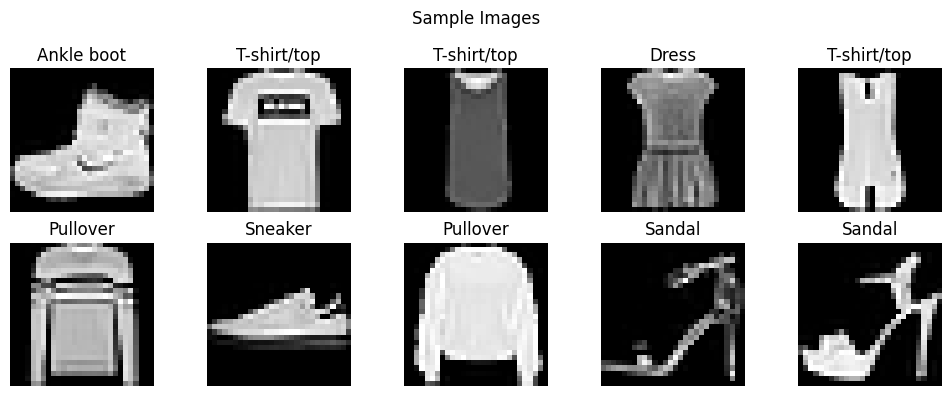

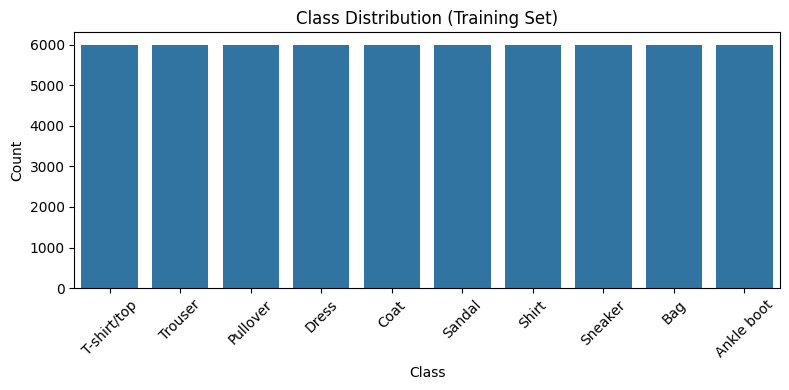

In [2]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print("Train images shape:", X_train_raw.shape)
print("Train labels shape:", y_train_raw.shape)
print("Test images shape:", X_test_raw.shape)
print("Test labels shape:", y_test_raw.shape)

# Sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(8,4))
sns.countplot(x=y_train_raw)
plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [3]:
print("Before preprocessing:")
print("X_train:", X_train_raw.shape, "dtype:", X_train_raw.dtype)

# Flatten and normalize
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("\nAfter preprocessing:")
print("X_train:", X_train.shape, "dtype:", X_train.dtype)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Before preprocessing:
X_train: (60000, 28, 28) dtype: uint8

After preprocessing:
X_train: (60000, 784) dtype: float32
y_train: (60000, 10)
X_test: (10000, 784)
y_test: (10000, 10)


In [4]:
def build_baseline_model():
    model = Sequential([
        keras.Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8215 - loss: 0.5017 - val_accuracy: 0.8548 - val_loss: 0.3870
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8649 - loss: 0.3702 - val_accuracy: 0.8635 - val_loss: 0.3758
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8781 - loss: 0.3323 - val_accuracy: 0.8677 - val_loss: 0.3621
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8871 - loss: 0.3072 - val_accuracy: 0.8723 - val_loss: 0.3677
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8926 - loss: 0.2894 - val_accuracy: 0.8705 - val_loss: 0.3652
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8977 - loss: 0.2735 - val_accuracy: 0.8733 - val_loss: 0.3572
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9028 - loss: 0.2601 - val_accuracy: 0.8737 - val_loss: 0.3540
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9069 - loss: 0.248

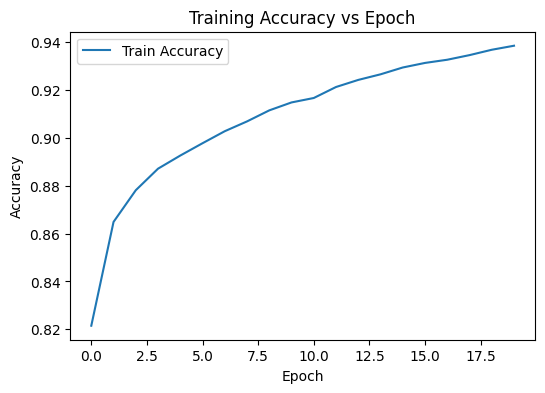

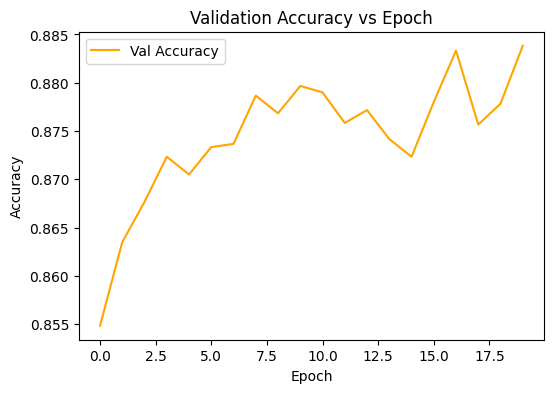

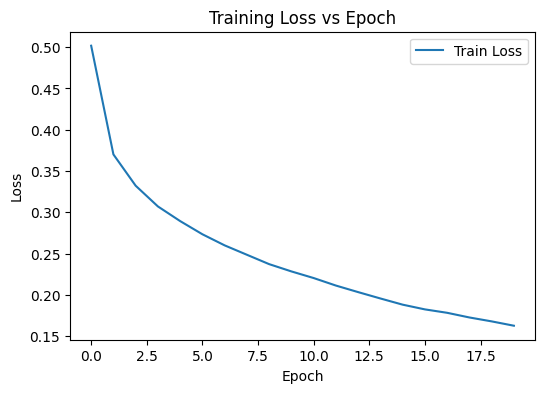

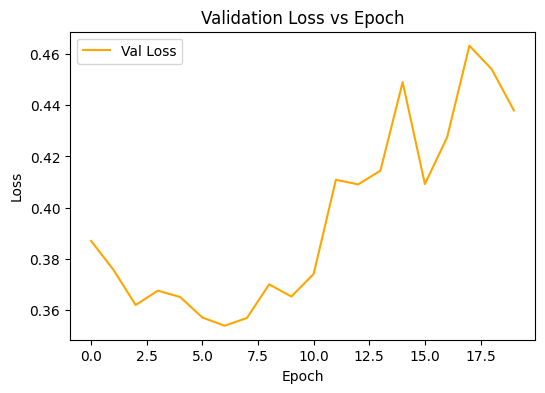

In [6]:
# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy:  0.8801
Baseline Precision: 0.8807
Baseline Recall:    0.8801
Baseline F1-score:  0.8786

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.76      0.90      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.79      0.81      0.80      1000
       Dress       0.83      0.92      0.87      1000
        Coat       0.83      0.75      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.75      0.61      0.68      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



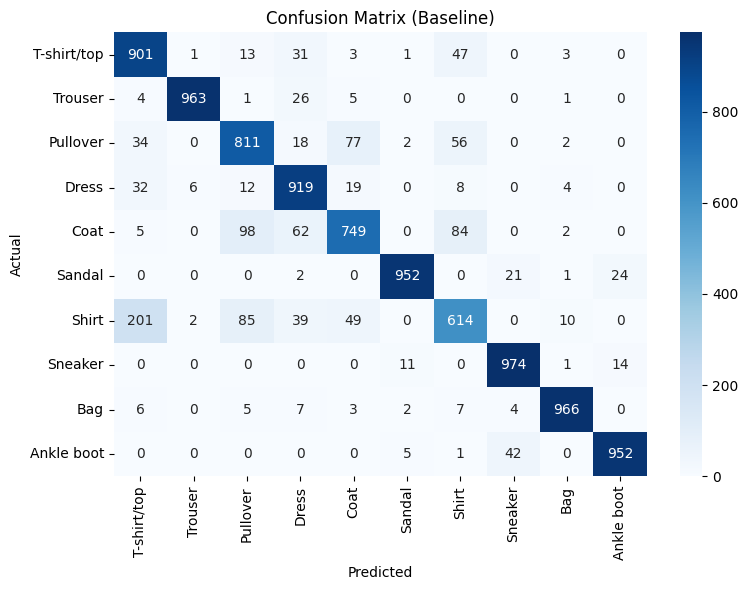

In [7]:
y_pred_probs = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average='macro')
baseline_rec = recall_score(y_true, y_pred, average='macro')
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall:    {baseline_rec:.4f}")
print(f"Baseline F1-score:  {baseline_f1:.4f}")

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
def build_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                 activation='relu', dropout_rate=0.0, optimizer_name='adam'):
    model = Sequential()
    model.add(keras.Input(shape=(784,)))
    model.add(Dense(hidden_neurons, activation=activation))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
# Use a subset for faster search (recommended on Colab CPU/GPU limits),
# then retrain best config on full data
from sklearn.model_selection import train_test_split
X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=0.3,
                                             stratify=y_train_raw, random_state=42)

keras_clf = KerasClassifier(
    model=build_model,
    verbose=0,
    hidden_layers=2,
    hidden_neurons=64,
    learning_rate=0.001,
    activation='relu',
    dropout_rate=0.0,
    optimizer_name='adam',
    epochs=10,
    batch_size=32
)

param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.0001, 0.001, 0.01],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
}

random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=10,          # increase if time permits
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

search_start = time.time()
random_search.fit(X_search, y_search)
search_time = time.time() - search_start

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)
print(f"Search time: {search_time:.2f} seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.01, model__optimizer_name=adam; total time=  22.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.01, model__optimizer_name=adam; total time=  24.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.01, model__optimizer_name=adam; total time=  23.8s
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=rmsprop; total time=  40.6s
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hi

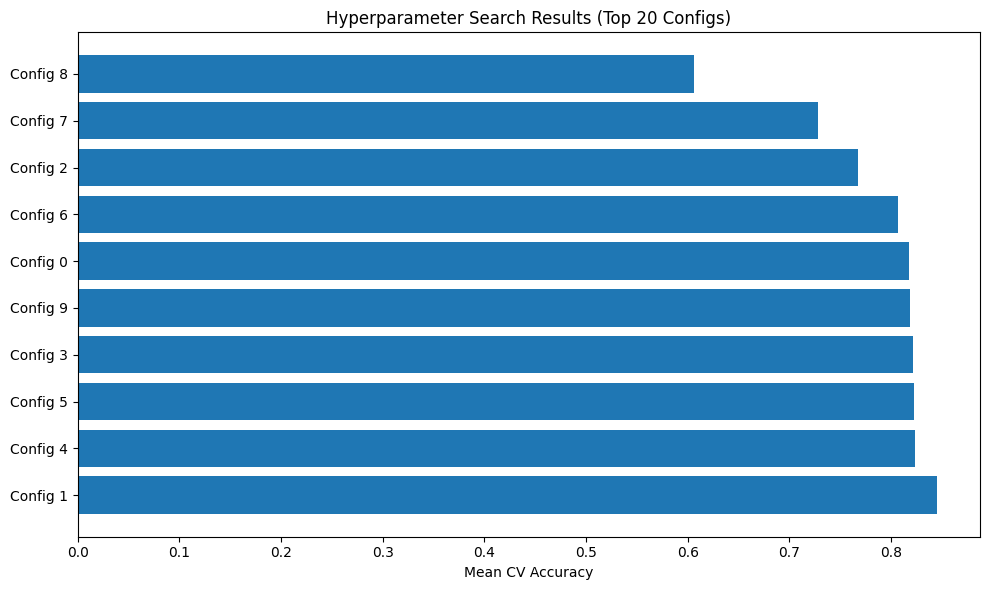

In [10]:
results_df = pd.DataFrame(random_search.cv_results_)
top_results = results_df.sort_values('mean_test_score', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_results)), top_results['mean_test_score'])
plt.yticks(range(len(top_results)), [f"Config {i}" for i in top_results.index])
plt.xlabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (Top 20 Configs)")
plt.tight_layout()
plt.show()

In [11]:
best_params = random_search.best_params_

optimized_model = build_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate'],
    optimizer_name=best_params['model__optimizer_name']
)

start_time = time.time()
opt_history = optimized_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - start_time
print(f"Optimized model training time: {optimized_train_time:.2f} seconds")

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7522 - loss: 0.6637 - val_accuracy: 0.8333 - val_loss: 0.4667
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.8362 - loss: 0.4599 - val_accuracy: 0.8565 - val_loss: 0.3961
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8514 - loss: 0.4237 - val_accuracy: 0.8662 - val_loss: 0.3925
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8599 - loss: 0.4058 - val_accuracy: 0.8680 - val_loss: 0.3872
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.8649 - loss: 0.3976 - val_accuracy: 0.8755 - val_loss: 0.3677
Epoch 6/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8692 - loss: 0.3853 - val_accuracy: 0.8753 - val_loss: 0.3737
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.8718 - loss: 0.3824 - val_accuracy: 0.8767 - val_loss: 0.3739
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8739 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Accuracy:  0.8721
Optimized Precision: 0.8723
Optimized Recall:    0.8721
Optimized F1-score:  0.8705


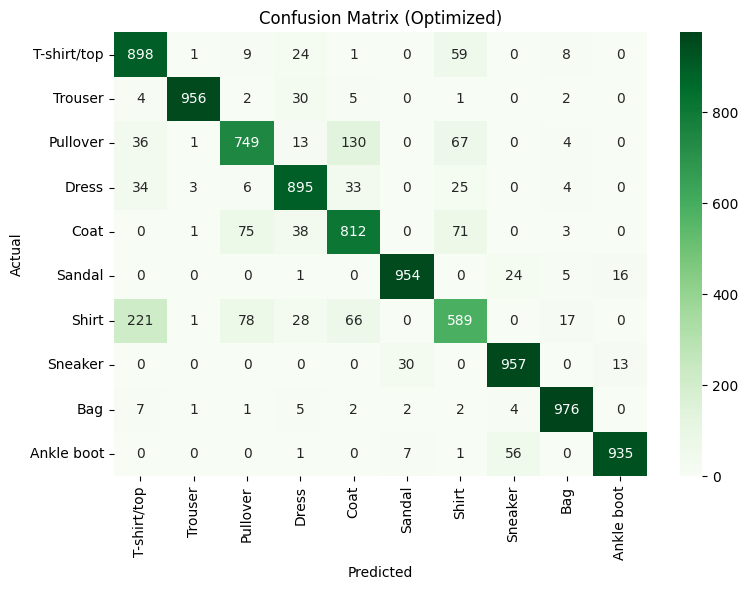

In [12]:
y_pred_opt_probs = optimized_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

opt_acc = accuracy_score(y_true, y_pred_opt)
opt_prec = precision_score(y_true, y_pred_opt, average='macro')
opt_rec = recall_score(y_true, y_pred_opt, average='macro')
opt_f1 = f1_score(y_true, y_pred_opt, average='macro')

print(f"Optimized Accuracy:  {opt_acc:.4f}")
print(f"Optimized Precision: {opt_prec:.4f}")
print(f"Optimized Recall:    {opt_rec:.4f}")
print(f"Optimized F1-score:  {opt_f1:.4f}")

cm_opt = confusion_matrix(y_true, y_pred_opt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Optimized)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

              Metric    Baseline   Optimized
0           Accuracy    0.880100    0.872100
1          Precision    0.880659    0.872342
2             Recall    0.880100    0.872100
3           F1-score    0.878600    0.870540
4  Training Time (s)  167.119921  205.291355


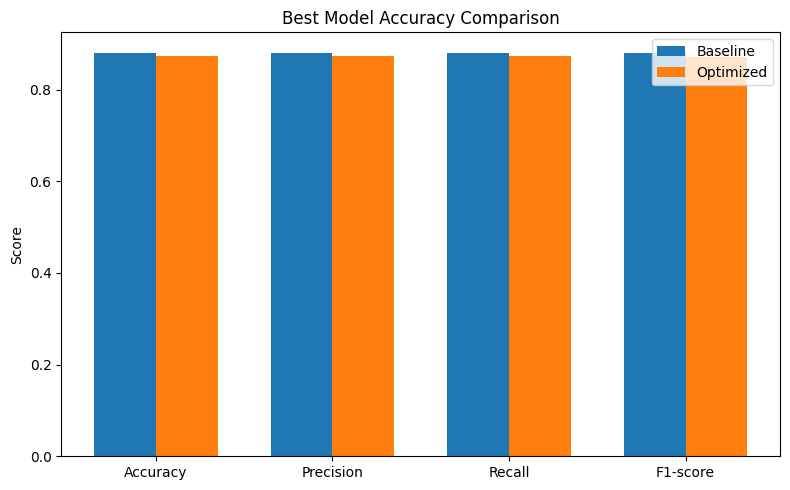

In [13]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    'Optimized': [opt_acc, opt_prec, opt_rec, opt_f1, optimized_train_time]
})
print(comparison_df)

x = np.arange(4)
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, comparison_df['Baseline'][:4], width, label='Baseline')
plt.bar(x + width/2, comparison_df['Optimized'][:4], width, label='Optimized')
plt.xticks(x, comparison_df['Metric'][:4])
plt.ylabel("Score")
plt.title("Best Model Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()